# ==========================================================
# TWITTER SENTIMENT ANALYSIS USING MACHINE LEARNING
# ==========================================================

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer
)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from wordcloud import WordCloud


In [2]:
# Download NLTK Data

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
# LOAD DATASET

# Dataset Columns:
# target, ids, date, flag, user, text

columns = [
    'target',
    'ids',
    'date',
    'flag',
    'user',
    'text'
]

df = pd.read_csv(
    '/content/training.1600000.processed.noemoticon.csv',
    encoding='latin-1',
    names=columns,
    on_bad_lines='skip', # Added to skip malformed lines
    engine='python' # Added to handle parsing errors more robustly
)

print(df.head())

   target         ids                          date      flag  \
0       0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY   
1       0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY   
2       0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY   
3       0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
4       0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   

              user                                               text  
0  _TheSpecialOne_  @switchfoot http://twitpic.com/2y1zl - Awww, t...  
1    scotthamilton  is upset that he can't update his Facebook by ...  
2         mattycus  @Kenichan I dived many times for the ball. Man...  
3          ElleCTF    my whole body feels itchy and like its on fire   
4           Karoli  @nationwideclass no, it's not behaving at all....  


In [14]:
# Select Required Columns

df = df[['target', 'text']]

# Convert labels:
# 0 = Negative
# 4 = Positive

df['target'] = df['target'].replace(4, 1)


# Reduce dataset size

df = df.sample(20000, random_state=42) # Changed sample size from 50000 to 20000

print("\nDataset Shape:", df.shape)
print("Target value counts after stratified sampling:\n", df['target'].value_counts())


Dataset Shape: (20000, 2)
Target value counts after stratified sampling:
 target
0    10000
1    10000
Name: count, dtype: int64


In [5]:
# TEXT PREPROCESSING


stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+", "", text)

    # Remove mentions
    text = re.sub(r"@\w+", "", text)

    # Remove hashtags
    text = re.sub(r"#\w+", "", text)

    # Remove special characters
    text = re.sub(r"[^a-zA-Z]", " ", text)

    words = text.split()

    cleaned_words = []

    for word in words:

        if word not in stop_words:

            stemmed_word = stemmer.stem(word)

            cleaned_words.append(stemmed_word)

    return " ".join(cleaned_words)


df['clean_text'] = df['text'].apply(clean_text)

print("\nCleaned Text Example:")
print(df['clean_text'].iloc[0])



Cleaned Text Example:
thank luv keep grind go like know u stay posit like u alway pray nippl god


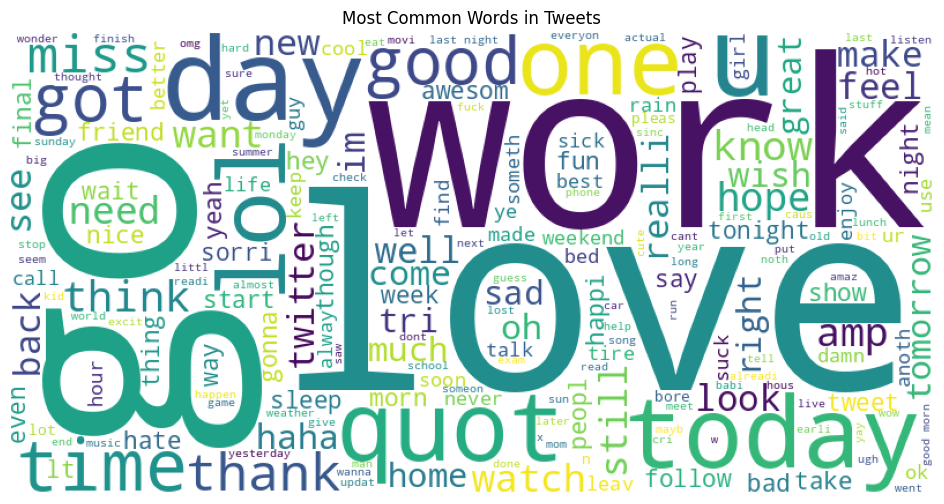

In [6]:
# WORD CLOUD VISUALIZATION

all_words = " ".join(df['clean_text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Most Common Words in Tweets")

plt.show()


In [7]:
# TRAIN TEST SPLIT

# Re-defining necessary NLTK components and cleaning function
# as 'clean_text' column appears to be missing from df.
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
nltk.download('stopwords', quiet=True)

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+", "", text)

    # Remove mentions
    text = re.sub(r"@\w+", "", text)

    # Remove hashtags
    text = re.sub(r"#\w+", "", text)

    # Remove special characters
    text = re.sub(r"[^a-zA-Z]", " ", text)

    words = text.split()

    cleaned_words = []

    for word in words:

        if word not in stop_words:

            stemmed_word = stemmer.stem(word)

            cleaned_words.append(stemmed_word)

    return " ".join(cleaned_words)

# Ensure 'clean_text' column is created before use
if 'clean_text' not in df.columns:
    print("Warning: 'clean_text' column not found. Re-applying text cleaning.")
    df['clean_text'] = df['text'].apply(clean_text)

X = df['clean_text']
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
# FEATURE EXTRACTION

# TF-IDF Vectorization

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)


# MODEL 1 - LOGISTIC REGRESSION

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)


# MODEL 2 - NAIVE BAYES

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)


# MODEL 3 - SVM

svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)


In [9]:
# EVALUATION FUNCTION


def evaluate_model(y_test, predictions, model_name):

    accuracy = accuracy_score(y_test, predictions)

    print("\n===================================")
    print(f"{model_name} Results")
    print("===================================")

    print("Accuracy:", accuracy)

    print("\nClassification Report:\n")

    print(classification_report(y_test, predictions))

    # -----------------------------
    # Confusion Matrix
    # -----------------------------
    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f"{model_name} Confusion Matrix")

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

    return accuracy


Logistic Regression Results
Accuracy: 0.73025

Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.71      0.73      2055
           1       0.71      0.76      0.73      1945

    accuracy                           0.73      4000
   macro avg       0.73      0.73      0.73      4000
weighted avg       0.73      0.73      0.73      4000



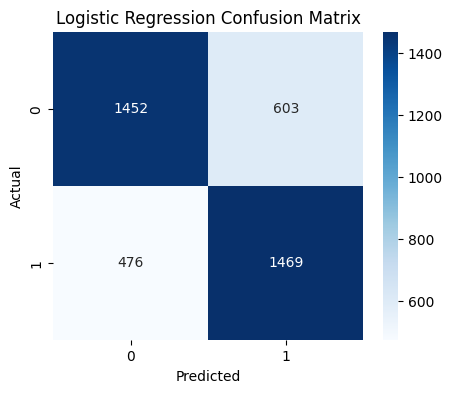


Naive Bayes Results
Accuracy: 0.7225

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.72      0.73      2055
           1       0.71      0.72      0.72      1945

    accuracy                           0.72      4000
   macro avg       0.72      0.72      0.72      4000
weighted avg       0.72      0.72      0.72      4000



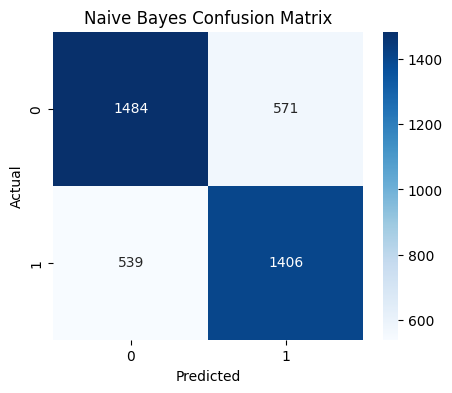


SVM Results
Accuracy: 0.72

Classification Report:

              precision    recall  f1-score   support

           0       0.74      0.70      0.72      2055
           1       0.70      0.74      0.72      1945

    accuracy                           0.72      4000
   macro avg       0.72      0.72      0.72      4000
weighted avg       0.72      0.72      0.72      4000



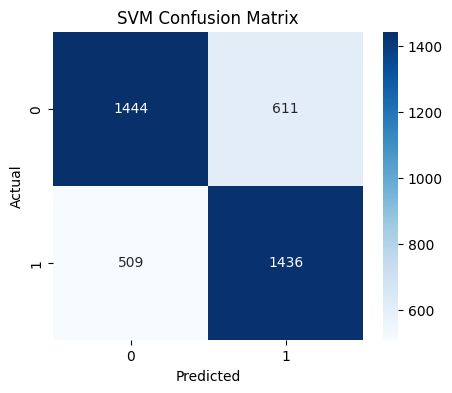

In [10]:
# MODEL EVALUATION


lr_acc = evaluate_model(
    y_test,
    lr_pred,
    "Logistic Regression"
)

nb_acc = evaluate_model(
    y_test,
    nb_pred,
    "Naive Bayes"
)

svm_acc = evaluate_model(
    y_test,
    svm_pred,
    "SVM"
)




In [11]:
# FINAL COMPARISON


results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Naive Bayes',
        'SVM'
    ],
    'Accuracy': [
        lr_acc,
        nb_acc,
        svm_acc
    ]
})

print("\n===================================")
print("FINAL MODEL COMPARISON")
print("===================================")

print(results)


FINAL MODEL COMPARISON
                 Model  Accuracy
0  Logistic Regression   0.73025
1          Naive Bayes   0.72250
2                  SVM   0.72000


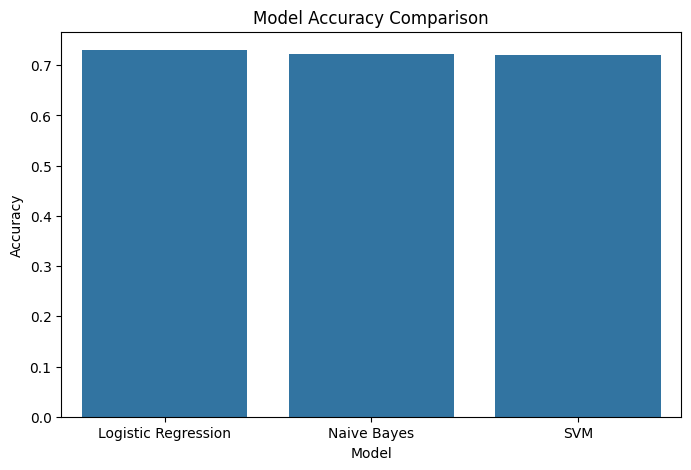

In [12]:
# COMPARISON GRAPH

plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results
)

plt.title("Model Accuracy Comparison")

plt.show()